## Visualize BCNN results

In [60]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import *
import torch.nn.functional as F
from collections import defaultdict

In [61]:
# Set model 
run_name = 'BCNN_ 20251107_173428_vgg16_2.pth'
run_name = 'BCNN_ 20251110_151131_vgg16_2.pth' # all final nodes
run_name = 'BCNN_ 20251111_181849_resnet50_2.pth' # all final nodes
run_name = 'BCNN_ 20251113_142023_resnet50_3.pth' # all final nodes

# Set paths
data_directory = '/data/WHOI-Plankton'
root_directory = os.path.abspath('')
weights_path = os.path.join(root_directory,'Models_results/weights', run_name)
predictions_path = os.path.join(root_directory, 'Models_results/predictions', run_name)
metadata_path = os.path.join(root_directory, 'Models_results/environment', run_name)

In [62]:
# # Load environment/metadata variables
metadata = torch.load(metadata_path, weights_only = False)
model_id, model_name = metadata['model_id'], metadata['model_name']
classes, class_ids = metadata['classes'], metadata['class_ids']
train_metrics = metadata['train_metrics']
hyperparameters = metadata['hyperparameters']
levels = metadata['levels']

print(hyperparameters)

# Load predictions
predictions = torch.load(predictions_path, map_location = torch.device('cpu'))
y_true = [[] for _ in range(levels)]
y_pred = [[] for _ in range(levels)]
y_prob = [[] for _ in range(levels)]

for l in range(levels):
    y_true[l] = predictions[0][l].numpy()
    y_pred[l] = predictions[2][l].numpy()
    y_prob[l] = predictions[1][l].numpy()

{'loss_fn': {'criterion': 'CrossEntropyLoss', 'alpha': [[0.5, 0.25, 0.25], [0.2, 0.4, 0.4], [0.1, 0.1, 0.8]], 'thresholds': [15, 20]}, 'optimizer': 'Adam', 'lr': 0.0005, 'epochs': 60, 'scheduler': {'type': 'CosineAnnealingLR', 'T_max': 50}, 'early_stopping': None, 'batch_size': 64}


In [63]:
# typo correction
if classes[0][1] == 'Multicellular':
    classes[0][1] = 'Unicellular'

### Train Performance

Model trained for 60 epochs.


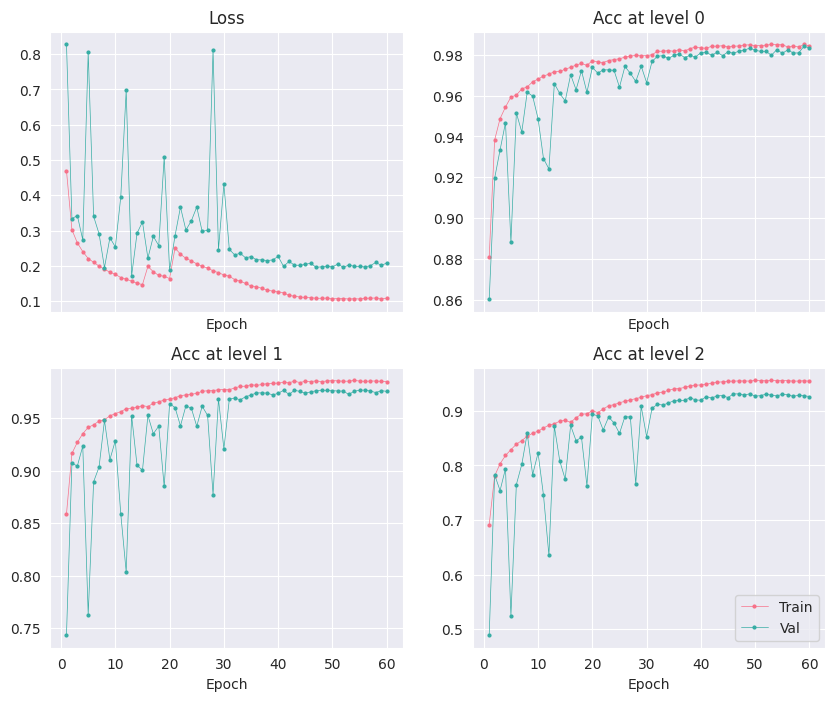

In [64]:
actual_epochs = len(train_metrics['train_acc'][0])
print(f'Model trained for {actual_epochs} epochs.')

# Plot
sns.set_style('darkgrid')
if levels == 2:
    fig, axes = plt.subplots(1, levels + 1, figsize = (14, 4), sharex = True)
elif levels == 3:
    fig, axes = plt.subplots(2, 2, figsize = (10, 8), sharex = True)
    axes = axes.flat


palette = sns.color_palette('husl', n_colors = 2)

metrics = ['loss', 'acc']
epochs_enum = list(range(1, actual_epochs+1))

indx = 0
for i, metric in enumerate(metrics):
   
    if metric == 'acc':
        for l in range(levels):
            train_values = train_metrics[f'train_{metric}'][l]
            val_values = train_metrics[f'test_{metric}'][l]

            axes[indx].plot(epochs_enum, train_values, label = f'Train', marker = 'o', markersize = 2, lw = 0.5, color = palette[0])
            axes[indx].plot(epochs_enum, val_values, label = f'Val', marker = 'o', markersize = 2, lw = 0.5, color = palette[1])
            
            axes[indx].set_title(metric.capitalize()+f' at level {l}')
            axes[indx].set_xlabel('Epoch')
            indx +=1
            
    else:
        train_values = train_metrics[f'train_{metric}']
        val_values = train_metrics[f'test_{metric}']

        axes[indx].plot(epochs_enum, train_values, label = f'Train', marker = 'o', markersize = 2, lw = 0.5, color = palette[0])
        axes[indx].plot(epochs_enum, val_values, label = f'Val', marker = 'o', markersize = 2, lw = 0.5, color = palette[1])
        
        axes[indx].set_title(metric.capitalize())
        axes[indx].set_xlabel('Epoch')
        indx +=1 
                
 
plt.legend()
plt.show()

### Test performance

In [65]:
# Compute overall metrics
for l in range(levels):
    acc = accuracy_score(y_true[l], y_pred[l])

    prec_avg = precision_score(y_true[l], y_pred[l], average = 'macro')
    prec_w_avg = precision_score(y_true[l], y_pred[l], average = 'weighted')

    recall_avg = recall_score(y_true[l], y_pred[l], average = 'macro')
    recall_w_avg = recall_score(y_true[l], y_pred[l], average = 'weighted')

    f1_avg = f1_score(y_true[l], y_pred[l], average = 'macro')
    f1_w_avg = f1_score(y_true[l], y_pred[l], average = 'weighted')

    ce = log_loss(y_true[l], y_prob[l])

    # Print
    print(f'Results for level: {l}\n')
    print(f'Accuracy: {acc:.4f}\n')
    print(f'Average Precision: {prec_avg:.4f}\nWeighted Precision: {prec_w_avg:.4f}\n')
    print(f'Average Recall: {recall_avg:.4f}\nWeighted Recall: {recall_w_avg:.4f}\n')
    print(f'Average F1: {f1_avg:.4f}\nWeighted F1: {f1_w_avg:.4f}\n')
    print(f'Cross Entropy: {ce:.4f}')
    print(f'----------------------------------\n')

Results for level: 0

Accuracy: 0.9815

Average Precision: 0.9717
Weighted Precision: 0.9816

Average Recall: 0.9735
Weighted Recall: 0.9815

Average F1: 0.9726
Weighted F1: 0.9815

Cross Entropy: 0.0502
----------------------------------

Results for level: 1

Accuracy: 0.9768

Average Precision: 0.9706
Weighted Precision: 0.9767

Average Recall: 0.9670
Weighted Recall: 0.9768

Average F1: 0.9688
Weighted F1: 0.9767

Cross Entropy: 0.0706
----------------------------------

Results for level: 2

Accuracy: 0.9248

Average Precision: 0.9178
Weighted Precision: 0.9248

Average Recall: 0.9051
Weighted Recall: 0.9248

Average F1: 0.9109
Weighted F1: 0.9247

Cross Entropy: 0.2367
----------------------------------



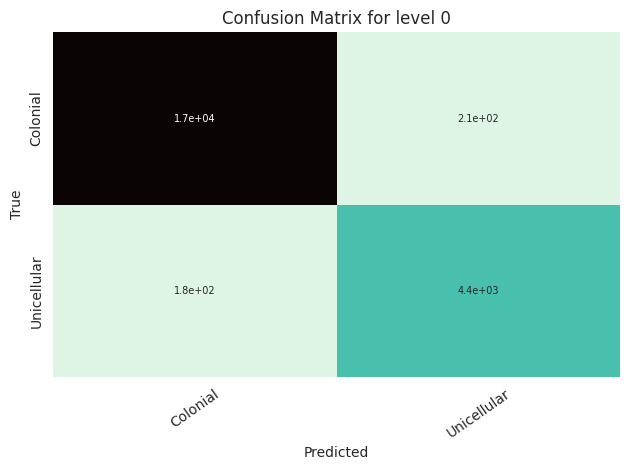

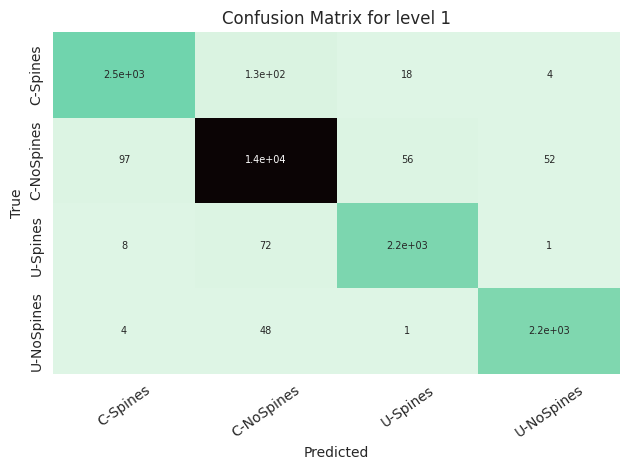

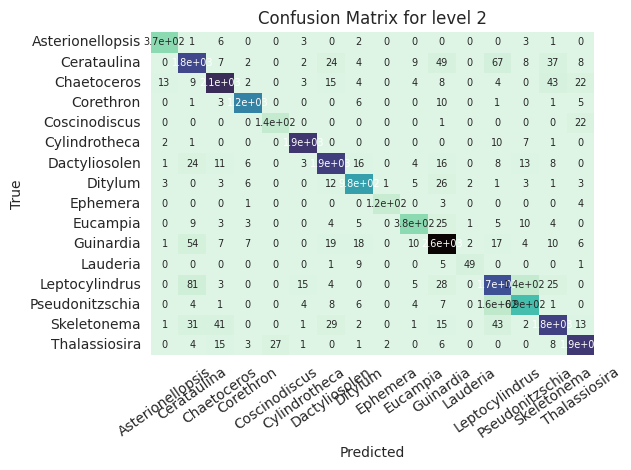

In [66]:
# Get confusion matrix data
for l in range(levels):
    cm = confusion_matrix(y_true[l], y_pred[l])
    annot_kws = {'size': 7}

    # Plot
    sns.heatmap(
        cm, annot = True, annot_kws = annot_kws, cmap = 'mako_r', 
        xticklabels = classes[l], yticklabels = classes[l], cbar = False
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for level {l}')
    plt.xticks(rotation = 35)

    plt.tight_layout()
    plt.show()

### Metrics per class

In [67]:
# Compute per class metrics
precision_list = []
recall_list = []
ce_list = []

for l in range(levels):
    precision_list.append(precision_score(y_true[l], y_pred[l], average = None))
    recall_list.append(recall_score(y_true[l], y_pred[l], average = None))

    # Cross-entropy
    y_true_tensor = torch.from_numpy(y_true[l]).long()
    y_logit_tensor = torch.from_numpy(y_prob[l]).float().log()

    ce_all = F.cross_entropy(y_logit_tensor, y_true_tensor, reduction = 'none')
    class_ces = defaultdict(list)

    for ce, y in zip(ce_all, y_true_tensor):
        class_ces[int(y)].append(ce.item())

    ce_per_class = np.full(len(classes[l]), np.nan)
    for clid in range(len(classes[l])):
        if class_ces[clid]:
            ce_per_class[clid] = np.mean(class_ces[clid])
    ce_list.append(ce_per_class)        

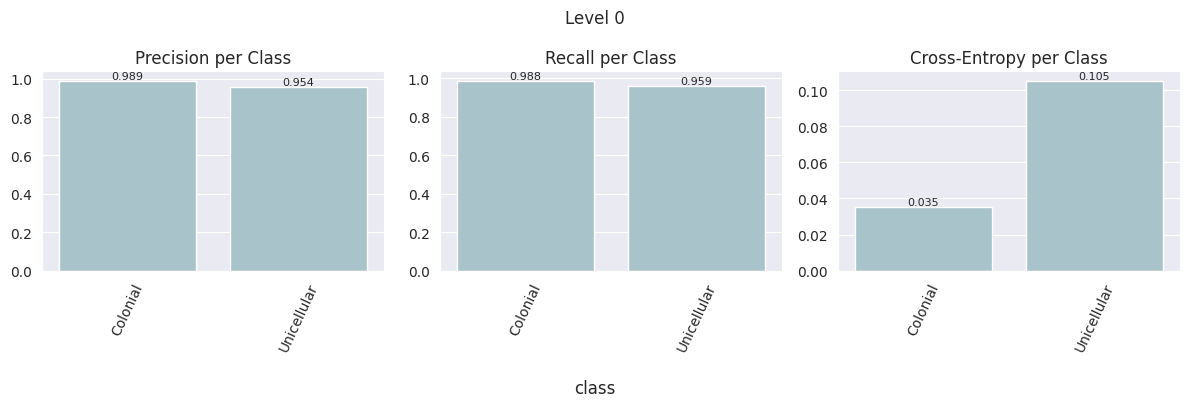

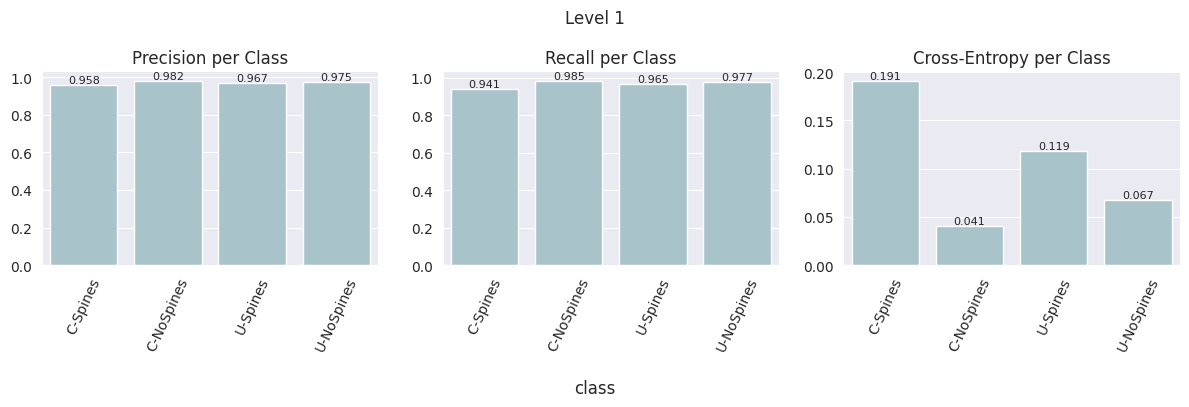

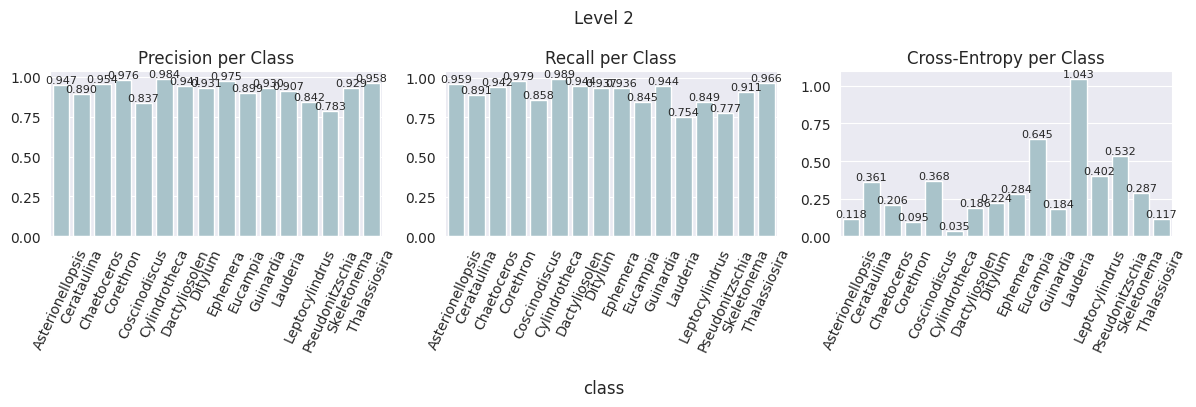

In [68]:
# Precision and Recall per class
for l in range(levels):
    sns.set_style('darkgrid')
    fig, axes = plt.subplots(1, 3, figsize = (12, 4), sharex = True)
    fig.supxlabel('class')
    fig.suptitle(f'Level {l}')
    
    # Precision
    sns.barplot(ax = axes[0],x = classes[l], y = precision_list[l], color = '#a3c6cf')
    axes[0].set_title('Precision per Class')
    axes[0].bar_label(axes[0].containers[0], fmt = '%.3f', fontsize = 8)
    axes[0].tick_params(axis = 'x', rotation = 65)
    # Recall
    sns.barplot(ax = axes[1],x = classes[l], y = recall_list[l], color = '#a3c6cf')
    axes[1].set_title('Recall per Class')
    axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', fontsize = 8)
    axes[1].tick_params(axis = 'x', rotation = 65)
    # CE
    sns.barplot(ax = axes[2],x = classes[l], y = ce_list[l], color = '#a3c6cf')
    axes[2].set_title('Cross-Entropy per Class')
    axes[2].bar_label(axes[2].containers[0], fmt = '%.3f', fontsize = 8)
    axes[2].tick_params(axis = 'x', rotation = 65)


    plt.tight_layout()
    plt.show()

## Check for contradictions

In [69]:
if levels ==2:

    preds_0 = np.array(y_pred[0])
    preds_fn = np.array(y_pred[levels-1])

    level0 = classes[0]
    final_nodes = classes[levels-1]
    num_contradictions = [[] for _ in range(2)]
    per_contradictions = [[] for _ in range(2)]

    # Classified as Unicelular but contradicted the final node

    non_unicellular = [
        'Asterionellopsis', 'Lauderia', 'Chaetoceros','Eucampia', 'Guinardia', 
        'Thalassiosira', 'Pseudonitzschia', 'Leptocylindrus', 'Skeletonema',
        'Dactyliosolen',  'Cerataulina'
        ]
    c_ci = level0.index('Unicellular') 

    for i, class_name in enumerate(non_unicellular):
        c_fi = final_nodes.index(class_name)
        indx = np.where([preds_fn == c_fi])
        num_contradictions[0].append(np.count_nonzero(preds_0[indx[1]]== c_ci))
        per_contradictions[0].append(
            np.count_nonzero(preds_0[indx[1]]== c_ci)/len(preds_0[indx[1]])
            )

    # Classified as Colonial but contradicted the final node

    non_colonial = [
        'Corethron', 'Ditylum', 'Cylindrotheca', 'Ephemera','Coscinodiscus',
        ]
    c_ci = level0.index('Colonial') 

    for i, class_name in enumerate(non_colonial):
        c_fi = final_nodes.index(class_name)
        indx = np.where([preds_fn == c_fi])
        num_contradictions[1].append(np.count_nonzero(preds_0[indx[1]]== c_ci))
        per_contradictions[1].append(
            np.count_nonzero(preds_0[indx[1]]== c_ci)/len(preds_0[indx[1]])
                )
            
    total_percentage = (
        sum(num_contradictions[0]) + sum(num_contradictions[1])
        ) / len(y_pred[0])

    # Print
    print(f'Overall percentage contradictions: {total_percentage:.4f}')
    
elif levels==3:
    
    preds_0 = np.array(y_pred[0])
    preds_1 = np.array(y_pred[1])
    preds_fn = np.array(y_pred[levels-1])

    level0 = classes[0]
    level1 = classes[1]
    final_nodes = classes[levels-1]

    num_contradictions01 = [[] for _ in range(2)]
    per_contradictions01 = [[] for _ in range(2)]

    num_contradictions02 = [[] for _ in range(2)]
    per_contradictions02 = [[] for _ in range(2)]

    num_contradictions12 = [[] for _ in range(4)]
    per_contradictions12 = [[] for _ in range(4)]

    ############### 1. Contradictions between level 0 and level 1 #################

    # a. Classified as Unicelular but contradicted the middle level

    non_unicellular_l1 = ['C-Spines', 'C-NoSpines']
    c_ci = level0.index('Unicellular') 

    for i, class_name in enumerate(non_unicellular_l1):
        c_fi = level1.index(class_name)
        indx = np.where([preds_1 == c_fi])
        num_contradictions01[0].append(np.count_nonzero(preds_0[indx[1]]== c_ci))
        per_contradictions01[0].append(
            np.count_nonzero(preds_0[indx[1]]== c_ci)/len(preds_0[indx[1]])
            )

    # a. Classified as Colonial but contradicted the middle level

    non_colonial_l1 = ['U-Spines', 'U-NoSpines']
    c_ci = level0.index('Colonial') 

    for i, class_name in enumerate(non_colonial_l1):
        c_fi = level1.index(class_name)
        indx = np.where([preds_1 == c_fi])
        num_contradictions01[1].append(np.count_nonzero(preds_0[indx[1]]== c_ci))
        per_contradictions01[1].append(
            np.count_nonzero(preds_0[indx[1]]== c_ci)/len(preds_0[indx[1]])
            )

    ############ 2. Contradictions between level 0 and final nodes #################

    # a. Classified as Unicelular but contradicted the final node

    non_unicellular_l0 = [
            'Asterionellopsis', 'Lauderia', 'Chaetoceros','Eucampia', 'Guinardia', 
            'Thalassiosira', 'Pseudonitzschia', 'Leptocylindrus', 'Skeletonema',
            'Dactyliosolen',  'Cerataulina'
            ]
    c_ci = level0.index('Unicellular') 


    for i, class_name in enumerate(non_unicellular_l0):
        c_fi = final_nodes.index(class_name)
        indx = np.where([preds_fn == c_fi])
        num_contradictions02[0].append(np.count_nonzero(preds_0[indx[1]]== c_ci))
        per_contradictions02[0].append(
            np.count_nonzero(preds_0[indx[1]]== c_ci)/len(preds_0[indx[1]])
            )

    # b. Classified as Colonial but contradicted the final node

    non_colonial_l0 = [
        'Corethron', 'Ditylum', 'Cylindrotheca', 'Ephemera','Coscinodiscus',
        ]
    c_ci = level0.index('Colonial') 

    for i, class_name in enumerate(non_colonial_l0):
        c_fi = final_nodes.index(class_name)
        indx = np.where([preds_fn == c_fi])
        num_contradictions02[1].append(np.count_nonzero(preds_0[indx[1]]== c_ci))
        per_contradictions02[1].append(
            np.count_nonzero(preds_0[indx[1]]== c_ci)/len(preds_0[indx[1]])
            )
        
    ############ 3. Contradictions between level 1 and final nodes #################

    # a. Classified as C-NoSpines but contradicted the final node

    non_cnospines_l0 = [
            'Chaetoceros','Lauderia','Asterionellopsis','Corethron',
            'Ditylum','Cylindrotheca', 'Ephemera', 'Coscinodiscus'
            ]
    c_ci = level1.index('C-NoSpines') 

    for i, class_name in enumerate(non_cnospines_l0):
        c_fi = final_nodes.index(class_name)
        indx = np.where([preds_fn == c_fi])
        num_contradictions12[0].append(np.count_nonzero(preds_1[indx[1]]== c_ci))
        per_contradictions12[0].append(
            np.count_nonzero(preds_1[indx[1]]== c_ci)/len(preds_1[indx[1]])
            )

    # b. Classified as C-Spines but contradicted the final node

    non_cspines_l0 = [
        'Eucampia', 'Pseudonitzschia', 'Leptocylindrus', 'Skeletonema',
        'Dactyliosolen', 'Thalassiosira', 'Guinardia', 'Cerataulina', 'Corethron',
        'Ditylum', 'Cylindrotheca', 'Coscinodiscus', 'Ephemera'
    ]

    c_ci = level1.index('C-Spines') 

    for i, class_name in enumerate(non_cspines_l0):
        c_fi = final_nodes.index(class_name)
        indx = np.where([preds_fn == c_fi])
        num_contradictions12[1].append(np.count_nonzero(preds_1[indx[1]]== c_ci))
        per_contradictions12[1].append(
            np.count_nonzero(preds_1[indx[1]]== c_ci)/len(preds_1[indx[1]])
            )

    # c. Classified as U-NoSpines but contradicted the final node

    non_uspines_l0 = [
        'Eucampia', 'Pseudonitzschia', 'Leptocylindrus', 'Skeletonema',
        'Dactyliosolen', 'Thalassiosira', 'Guinardia', 'Cerataulina', 
        'Cylindrotheca', 'Coscinodiscus', 'Ephemera', 'Chaetoceros','Lauderia',
        'Asterionellopsis'
    ]
    c_ci = level1.index('U-Spines') 

    for i, class_name in enumerate(non_uspines_l0):
        c_fi = final_nodes.index(class_name)
        indx = np.where([preds_fn == c_fi])
        num_contradictions12[2].append(np.count_nonzero(preds_1[indx[1]]== c_ci))
        per_contradictions12[2].append(
            np.count_nonzero(preds_1[indx[1]]== c_ci)/len(preds_1[indx[1]])
            )
        
    # d. Classified as U-Spines but contradicted the final node

    non_unospines_l0 = [
        'Eucampia', 'Pseudonitzschia', 'Leptocylindrus', 'Skeletonema',
        'Dactyliosolen', 'Thalassiosira', 'Guinardia', 'Cerataulina', 
        'Chaetoceros','Lauderia', 'Corethron','Ditylum', 'Asterionellopsis'
    ]
    c_ci = level1.index('U-NoSpines') 

    for i, class_name in enumerate(non_unospines_l0):
        c_fi = final_nodes.index(class_name)
        indx = np.where([preds_fn == c_fi])
        num_contradictions12[3].append(np.count_nonzero(preds_1[indx[1]]== c_ci))
        per_contradictions12[3].append(
            np.count_nonzero(preds_1[indx[1]]== c_ci)/len(preds_1[indx[1]])
            )
        
    percentage_01 = (
    sum(num_contradictions01[0]) + sum(num_contradictions01[1])
    )/ len(y_pred[0])
    percentage_02 = (
        sum(num_contradictions02[0]) + sum(num_contradictions02[1])
        ) / len(y_pred[0])
    percentage_12 = (
        sum(num_contradictions12[0]) + sum(num_contradictions12[1]) + 
        sum(num_contradictions12[2]) + sum(num_contradictions12[3]) 
    )/ len(y_pred[0])

    print(f'Overall percentage contradictions between level 0 and 1 : {percentage_01:.4f}\n')
    print(f'Overall percentage contradictions between level 0 and final nodes : {percentage_02:.4f}\n')
    print(f'Overall percentage contradictions between level 1 and final nodes : {percentage_12:.4f}\n')


Overall percentage contradictions between level 0 and 1 : 0.0127

Overall percentage contradictions between level 0 and final nodes : 0.0146

Overall percentage contradictions between level 1 and final nodes : 0.0126



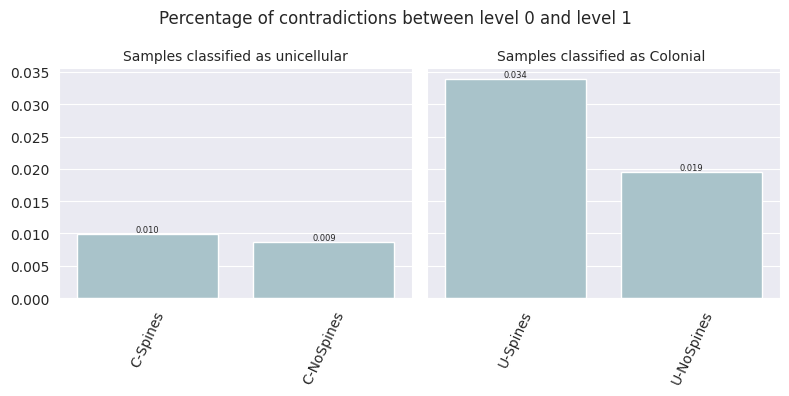

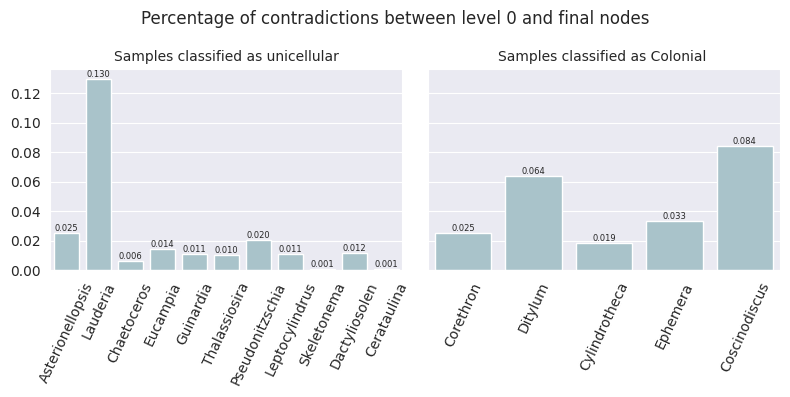

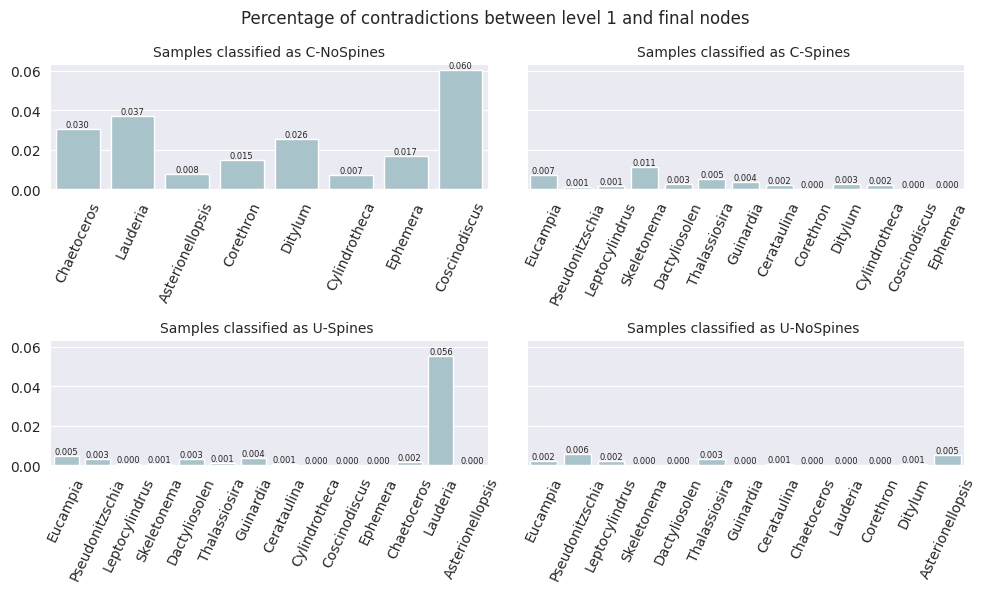

In [71]:
if levels == 2:

    sns.set_style('darkgrid')
    fig, axes = plt.subplots(2, 1, figsize = (8, 8),sharey=True)


    sns.barplot(ax = axes[0],x = non_unicellular, y = per_contradictions[0], color = '#a3c6cf')
    axes[0].set_title('Percentage of samples classified as Unicellular but contradicting final node')
    axes[0].bar_label(axes[0].containers[0], fmt = '%.3f', fontsize = 8)
    axes[0].tick_params(axis = 'x', rotation = 65)


    sns.barplot(ax = axes[1],x = non_colonial, y = per_contradictions[1], color = '#a3c6cf')
    axes[1].set_title('Percentage of samples classified as Colonial but contradicting final node')
    axes[1].bar_label(axes[1].containers
                      [0], fmt = '%.3f', fontsize = 8)
    axes[1].tick_params(axis = 'x', rotation = 65)

    plt.tight_layout()
    plt.show()
    
elif levels == 3:
    
        # Level 0 and level 1
    sns.set_style('darkgrid')
    fig, axes = plt.subplots(1, 2, figsize = (8, 4),sharey=True)
    axes = axes.flat
    fig.suptitle('Percentage of contradictions between level 0 and level 1')
    sns.barplot(ax = axes[0],x = non_unicellular_l1, y = per_contradictions01[0], color = '#a3c6cf')
    axes[0].set_title('Samples classified as unicellular',fontsize = 10)
    axes[0].bar_label(axes[0].containers[0], fmt = '%.3f', fontsize = 6)
    axes[0].tick_params(axis = 'x', rotation = 65)


    sns.barplot(ax = axes[1],x = non_colonial_l1, y = per_contradictions01[1], color = '#a3c6cf')
    axes[1].set_title('Samples classified as Colonial ', fontsize = 10)
    axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', fontsize = 6)
    axes[1].tick_params(axis = 'x', rotation = 65)

    plt.tight_layout()
    plt.show()

    # Level 0 and final nodes
    fig, axes = plt.subplots(1, 2, figsize = (8, 4),sharey=True)
    axes = axes.flat
    fig.suptitle('Percentage of contradictions between level 0 and final nodes')
    sns.barplot(ax = axes[0],x = non_unicellular_l0, y = per_contradictions02[0], color = '#a3c6cf')
    axes[0].set_title('Samples classified as unicellular',fontsize = 10)
    axes[0].bar_label(axes[0].containers[0], fmt = '%.3f', fontsize = 6)
    axes[0].tick_params(axis = 'x', rotation = 65)


    sns.barplot(ax = axes[1],x = non_colonial_l0, y = per_contradictions02[1], color = '#a3c6cf')
    axes[1].set_title('Samples classified as Colonial ', fontsize = 10)
    axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', fontsize = 6)
    axes[1].tick_params(axis = 'x', rotation = 65)

    plt.tight_layout()
    plt.show()

    # Level 1 and final nodes
    fig, axes = plt.subplots(2, 2, figsize = (10, 6),sharey=True)
    axes = axes.flat
    fig.suptitle('Percentage of contradictions between level 1 and final nodes')
    sns.barplot(ax = axes[0],x = non_cnospines_l0, y = per_contradictions12[0], color = '#a3c6cf')
    axes[0].set_title('Samples classified as C-NoSpines',fontsize = 10)
    axes[0].bar_label(axes[0].containers[0], fmt = '%.3f', fontsize = 6)
    axes[0].tick_params(axis = 'x', rotation = 65)


    sns.barplot(ax = axes[1],x = non_cspines_l0, y = per_contradictions12[1], color = '#a3c6cf')
    axes[1].set_title('Samples classified as C-Spines ', fontsize = 10)
    axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', fontsize = 6)
    axes[1].tick_params(axis = 'x', rotation = 65)

    sns.barplot(ax = axes[2],x = non_uspines_l0, y = per_contradictions12[2], color = '#a3c6cf')
    axes[2].set_title('Samples classified as U-Spines ', fontsize = 10)
    axes[2].bar_label(axes[2].containers[0], fmt = '%.3f', fontsize = 6)
    axes[2].tick_params(axis = 'x', rotation = 65)

    sns.barplot(ax = axes[3],x = non_unospines_l0, y = per_contradictions12[3], color = '#a3c6cf')
    axes[3].set_title('Samples classified as U-NoSpines ', fontsize = 10)
    axes[3].bar_label(axes[3].containers[0], fmt = '%.3f', fontsize = 6)
    axes[3].tick_params(axis = 'x', rotation = 65)

    plt.tight_layout()
    plt.show()